# 02 Single Run (Complete)

Complete single-run comparison on a fixed stream: uniform, epsilon-greedy, LinUCB-raw, softmax router, and oracle.


In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
project_root = next((p for p in candidates if (p / 'moe_bandit').exists()), None)
if project_root is None:
    raise RuntimeError("Could not find project root containing 'moe_bandit'.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from moe_bandit.data import generate_synthetic_data
from moe_bandit.experts import train_experts, expert_reward_matrix
from moe_bandit.policies import (
    EpsilonGreedyPolicy,
    LinUCBPolicy,
    UniformRandomPolicy,
    train_softmax_router,
)
from moe_bandit.runner import run_bandit


In [20]:
# Locked default config from Implementation Plan
K = 4
d = 10
cluster_sep = 2.0
cluster_std = 1.0
contamination = 0.20
n_train_per_cluster = 2000

seed_train_data = 101
seed_train_experts = 202
seed_bandit_stream = 303
seed_policy = 404

n_train = K * n_train_per_cluster
T = 10000
clip_eps = 1e-3
linucb_alpha = 1.0
linucb_lambda = 1.0
forced_explore_per_arm = 20

X_train, y_train, cluster_train = generate_synthetic_data(
    n_samples=n_train, K=K, d=d, cluster_sep=cluster_sep, cluster_std=cluster_std, seed=seed_train_data
)
experts = train_experts(
    X_train=X_train,
    y_train=y_train,
    cluster_id_train=cluster_train,
    K=K,
    d=d,
    epochs=30,
    lr=1e-3,
    batch_size=64,
    seed=seed_train_experts,
    contamination=contamination,
)

X_bandit_raw, y_bandit, cluster_bandit = generate_synthetic_data(
    n_samples=T, K=K, d=d, cluster_sep=cluster_sep, cluster_std=cluster_std, seed=seed_bandit_stream
)
R_raw = expert_reward_matrix(experts=experts, X=X_bandit_raw, y=y_bandit, clip_eps=clip_eps)

# Main-pipeline preprocessing: reward rescale + context standardization
R = (R_raw - np.log(clip_eps)) / (-np.log(clip_eps))
x_mu = X_bandit_raw.mean(axis=0)
x_sigma = X_bandit_raw.std(axis=0)
x_sigma = np.where(x_sigma < 1e-12, 1.0, x_sigma)
X_bandit = (X_bandit_raw - x_mu) / x_sigma

print('X_bandit shape:', X_bandit.shape)
print('R shape:', R.shape)


X_bandit shape: (10000, 10)
R shape: (10000, 4)


In [21]:
# Train in-sample supervised softmax router baseline from oracle labels argmax(R, axis=1)
# Note: this is intentionally in-sample as an optimistic supervised-router baseline.
softmax_router_policy = train_softmax_router(
    X_train=X_bandit,
    R_train=R,
    hidden_dim=64,
    epochs=300,
    batch_size=64,
    lr=1e-3,
    seed=seed_policy,
)


In [22]:
# Run all policies on the exact same (X, R) stream
uniform_policy = UniformRandomPolicy(K=K, seed=seed_policy)
eps_policy = EpsilonGreedyPolicy(K=K, c=50.0, seed=seed_policy)
linucb_raw_policy = LinUCBPolicy(
    K=K,
    d=d,
    alpha=linucb_alpha,
    lambda_reg=linucb_lambda,
    forced_explore_per_arm=forced_explore_per_arm,
    seed=seed_policy,
)

uniform_result = run_bandit(policy=uniform_policy, X=X_bandit, R=R, seed=seed_policy)
eps_result = run_bandit(policy=eps_policy, X=X_bandit, R=R, seed=seed_policy)
linucb_raw_result = run_bandit(policy=linucb_raw_policy, X=X_bandit, R=R, seed=seed_policy)
softmax_router_result = run_bandit(policy=softmax_router_policy, X=X_bandit, R=R, seed=seed_policy)

oracle_reward = R.max(axis=1)
oracle_regret = np.zeros_like(oracle_reward)

print('final cumulative regret:')
print('  uniform        :', float(uniform_result.cumulative_regret()[-1]))
print('  epsilon-greedy :', float(eps_result.cumulative_regret()[-1]))
print('  linucb-raw     :', float(linucb_raw_result.cumulative_regret()[-1]))
print('  softmax-router :', float(softmax_router_result.cumulative_regret()[-1]))
print('  oracle         :', float(np.cumsum(oracle_regret)[-1]))


final cumulative regret:
  uniform        : 1070.7416016295408
  epsilon-greedy : 1084.2771414393019
  linucb-raw     : 874.3346817867658
  softmax-router : 999.744722571243
  oracle         : 0.0


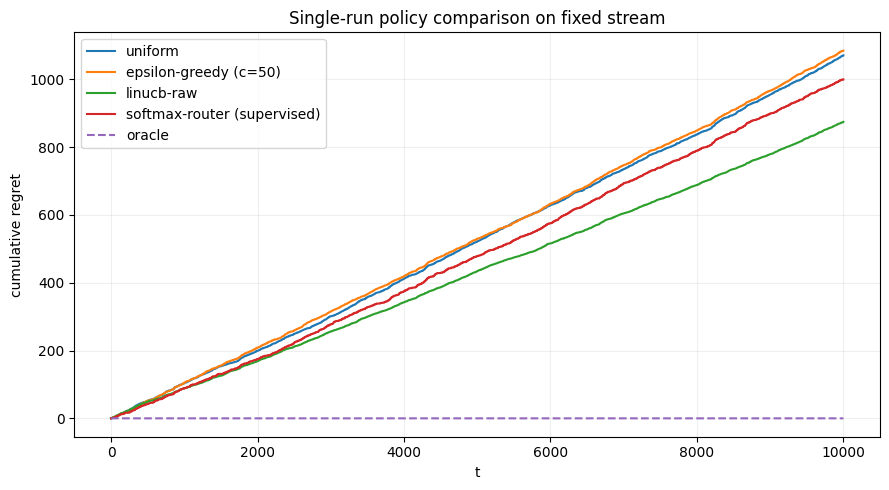

In [23]:
# Cumulative regret plot (single seed)
plt.figure(figsize=(9, 5))
plt.plot(uniform_result.cumulative_regret(), label='uniform')
plt.plot(eps_result.cumulative_regret(), label='epsilon-greedy (c=50)')
plt.plot(linucb_raw_result.cumulative_regret(), label='linucb-raw')
plt.plot(softmax_router_result.cumulative_regret(), label='softmax-router (supervised)')
plt.plot(np.cumsum(oracle_regret), label='oracle', linestyle='--')
plt.xlabel('t')
plt.ylabel('cumulative regret')
plt.title('Single-run policy comparison on fixed stream')
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
# Pull-count and policy-state diagnostics
print('epsilon-greedy pull counts:', np.bincount(eps_result.chosen_arm, minlength=K).tolist())
print('linucb-raw pull counts   :', linucb_raw_policy.pull_counts.tolist())
print('softmax-router pull counts:', np.bincount(softmax_router_result.chosen_arm, minlength=K).tolist())
print('uniform reference T/K    :', T / K)


epsilon-greedy pull counts: [80, 67, 64, 4789]
linucb-raw pull counts   : [1249, 1276, 1188, 1287]
softmax-router pull counts: [1205, 1353, 1177, 1265]
uniform reference T/K    : 1250.0
